<a href="https://colab.research.google.com/github/nehalahane22-sketch/DeepFER-Facial-Emotion-Recognition-Using-Deep-Learning/blob/main/FaceDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Upload your zip file using the left sidebar panel (Files icon) or run this cell:
from google.colab import files
uploaded = files.upload()  # Select your zip file (e.g., images.zip)

# Unzip the dataset directly into the Colab environment
!unzip -q images.zip -d ./

Saving Face Emotion Recognition Dataset.zip to Face Emotion Recognition Dataset.zip
unzip:  cannot find or open images.zip, images.zip.zip or images.zip.ZIP.


In [2]:
!ls -la


total 123416
drwxr-xr-x 1 root root      4096 Aug 27 17:37  .
drwxr-xr-x 1 root root      4096 Aug 27 17:20  ..
drwxr-xr-x 4 root root      4096 Aug 24 13:27  .config
-rw-r--r-- 1 root root 126358582 Aug 27 17:37 'Face Emotion Recognition Dataset.zip'
drwxr-xr-x 1 root root      4096 Aug 24 13:28  sample_data


In [3]:
!unzip -q "Face Emotion Recognition Dataset.zip" -d ./

In [4]:
!ls -la

total 123420
drwxr-xr-x 1 root root      4096 Aug 27 17:37  .
drwxr-xr-x 1 root root      4096 Aug 27 17:20  ..
drwxr-xr-x 4 root root      4096 Aug 24 13:27  .config
-rw-r--r-- 1 root root 126358582 Aug 27 17:37 'Face Emotion Recognition Dataset.zip'
drwxr-xr-x 5 root root      4096 Aug 27 17:38  images
drwxr-xr-x 1 root root      4096 Aug 24 13:28  sample_data


In [5]:
!ls -la images

total 20
drwxr-xr-x 5 root root 4096 Aug 27 17:38 .
drwxr-xr-x 1 root root 4096 Aug 27 17:37 ..
drwxr-xr-x 4 root root 4096 Aug 27 17:37 images
drwxr-xr-x 9 root root 4096 Aug 27 17:38 train
drwxr-xr-x 9 root root 4096 Aug 27 17:38 validation


In [6]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models, optimizers, callbacks
from sklearn.metrics import classification_report, confusion_matrix


In [8]:
# ==========================================
# 1. AUTO-DETECT DATASET PATHS
# ==========================================

# Check whether the dataset has this structure:
# ./images/
#     ├── train/
#     └── validation/
if os.path.exists("./images/train"):

    # If ./images/train exists, use ./images as the main dataset folder
    DATASET_PATH = "./images"


# If the first structure does not exist, check whether the dataset
# has an additional "images" folder inside it:
#
# ./images/
#     └── images/
#         ├── train/
#         └── validation/
elif os.path.exists("./images/images/train"):

    # In this case, use ./images/images as the dataset folder
    DATASET_PATH = "./images/images"


# If neither of the expected folder structures exists,
# stop the program and display an error message.
else:
    raise FileNotFoundError(
        "Could not find 'train' folder. Please check '!ls images'"
    )


# Create the complete path to the training dataset.
# Example:
# DATASET_PATH = "./images"
# TRAIN_DIR = "./images/train"
TRAIN_DIR = os.path.join(DATASET_PATH, "train")


# Create the complete path to the validation dataset.
# Example:
# DATASET_PATH = "./images"
# VAL_DIR = "./images/validation"
VAL_DIR = os.path.join(DATASET_PATH, "validation")


# Display the paths so we can verify that the dataset
# was detected correctly.
print(f"Training Directory: {TRAIN_DIR}")
print(f"Validation Directory: {VAL_DIR}")


# Define the height of every input image.
# MobileNetV2 will receive images resized to 224 pixels high.
IMG_HEIGHT = 224


# Define the width of every input image.
# Therefore, every image will become 224 x 224 pixels.
IMG_WIDTH = 224


# Number of images processed together in one training step.
# Here, the model processes 32 images at a time.
BATCH_SIZE = 32


# Number of emotion categories/classes in the dataset.
# For example, a typical facial emotion dataset may contain:
#
# 0 = Angry
# 1 = Disgust
# 2 = Fear
# 3 = Happy
# 4 = Sad
# 5 = Surprise
# 6 = Neutral
#
# Therefore, NUM_CLASSES = 7.
NUM_CLASSES = 7


# Number of complete passes through the training dataset.
# The model will train for a maximum of 15 epochs.
EPOCHS = 15

Training Directory: ./images/train
Validation Directory: ./images/validation


In [9]:
# ==========================================
# 2. DATA INTEGRITY & CLEANING (10% Rubric)
# ==========================================

# Define a function that checks the dataset for corrupted/empty image files.
def verify_dataset(data_dir):

    # Keep track of how many corrupted files are found and removed.
    corrupted_files = 0

    # os.walk() goes through the given directory and all its
    # subdirectories.
    #
    # For example:
    #
    # train/
    # ├── angry/
    # ├── happy/
    # ├── sad/
    # └── ...
    #
    # os.walk() will visit every emotion folder and inspect
    # the files inside it.
    for root, _, files in os.walk(data_dir):

        # Check every file found inside the dataset.
        for file in files:

            # Only process image files with these extensions.
            # lower() makes the check case-insensitive.
            #
            # Therefore, files such as:
            # image.jpg
            # image.JPG
            # image.png
            # image.JPEG
            #
            # can all be detected.
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):

                # Create the complete path to the image file.
                filepath = os.path.join(root, file)

                # Check whether the image file has zero bytes.
                #
                # A file with size 0 bytes contains no actual image
                # data and is considered an empty/corrupted file.
                if os.path.getsize(filepath) == 0:

                    # Delete the corrupted/empty image file.
                    os.remove(filepath)

                    # Increase the corrupted-file counter by 1.
                    corrupted_files += 1

    # Display a summary after checking the entire directory.
    #
    # os.path.basename(data_dir) extracts only the folder name.
    # For example:
    # ./images/train → train
    # ./images/validation → validation
    print(
        f"Data verification complete for "
        f"{os.path.basename(data_dir)}. "
        f"Removed corrupted files: {corrupted_files}"
    )



# Check all images inside the training directory.
verify_dataset(TRAIN_DIR)


# Check all images inside the validation directory.
verify_dataset(VAL_DIR)


Data verification complete for train. Removed corrupted files: 0
Data verification complete for validation. Removed corrupted files: 0


In [10]:
# ==========================================
# 3. PREPROCESSING & AUGMENTATION (15% Rubric)
# ==========================================

# Create an ImageDataGenerator for the training dataset.
#
# ImageDataGenerator automatically loads images, preprocesses them,
# and applies random transformations to training images.
train_datagen = ImageDataGenerator(

    # Normalize pixel values from the range 0–255
    # to the range 0–1.
    #
    # Example:
    # Original pixel = 255
    # After rescaling = 255 / 255 = 1.0
    #
    # Original pixel = 128
    # After rescaling = 128 / 255 ≈ 0.502
    rescale=1.0/255.0,

    # Randomly rotate images by up to ±20 degrees.
    # This helps the model recognize faces even when the face
    # is slightly tilted.
    rotation_range=20,

    # Randomly shift the image horizontally by up to 10%
    # of its total width.
    #
    # This helps the model handle faces that are not perfectly
    # centered in the image.
    width_shift_range=0.1,

    # Randomly shift the image vertically by up to 10%
    # of its total height.
    #
    # This helps the model handle faces positioned slightly
    # higher or lower in the image.
    height_shift_range=0.1,

    # Apply random shearing transformation.
    # This slightly changes the geometry of the image and
    # helps the model become less sensitive to small distortions.
    shear_range=0.15,

    # Randomly zoom in or out by up to 15%.
    # This helps the model recognize faces at slightly
    # different scales.
    zoom_range=0.15,

    # Randomly flip images horizontally.
    #
    # This is useful for facial emotion recognition because
    # a horizontally flipped face can still represent the
    # same emotion.
    horizontal_flip=True,

    # When transformations create empty areas around the image,
    # fill those areas using the nearest pixel values.
    fill_mode='nearest'
)


# ==========================================
# VALIDATION DATA PREPROCESSING
# ==========================================

# Create a separate generator for validation images.
#
# Validation images are ONLY normalized.
# We do NOT apply random augmentation because validation data
# should represent the original/unmodified data used to evaluate
# the model.
val_datagen = ImageDataGenerator(
    rescale=1.0/255.0
)


# ==========================================
# TRAINING DATA GENERATOR
# ==========================================

# Load training images from the directory structure.
train_generator = train_datagen.flow_from_directory(

    # Location of the training dataset.
    TRAIN_DIR,

    # Resize every image to 224 x 224 pixels.
    # This is the input size used by MobileNetV2.
    target_size=(IMG_HEIGHT, IMG_WIDTH),

    # Load 32 images at a time.
    batch_size=BATCH_SIZE,

    # Convert the emotion labels into one-hot encoded vectors.
    #
    # Example:
    # Angry = [1,0,0,0,0,0,0]
    # Happy = [0,0,0,1,0,0,0]
    class_mode='categorical',

    # Randomize the order of training images.
    # This prevents the model from learning based on the
    # original ordering of the files.
    shuffle=True
)


# ==========================================
# VALIDATION DATA GENERATOR
# ==========================================

# Load validation images from the validation directory.
val_generator = val_datagen.flow_from_directory(

    # Location of the validation dataset.
    VAL_DIR,

    # Resize validation images to 224 x 224 pixels.
    target_size=(IMG_HEIGHT, IMG_WIDTH),

    # Process 32 validation images at a time.
    batch_size=BATCH_SIZE,

    # Use categorical labels because there are 7 emotion classes.
    class_mode='categorical',

    # Do NOT shuffle validation data.
    #
    # Keeping a fixed order makes evaluation and comparison
    # of predictions easier and reproducible.
    shuffle=False
)


Found 28821 images belonging to 7 classes.
Found 7066 images belonging to 7 classes.


In [11]:
# ==========================================
# 4. MODEL BUILDING & TRANSFER LEARNING (20% Rubric)
# ==========================================

# Load the MobileNetV2 architecture with weights that were
# already trained on the ImageNet dataset.
#
# ImageNet contains millions of images, so the pre-trained
# MobileNetV2 has already learned useful general visual
# features such as edges, shapes, textures, and patterns.
#
# weights='imagenet':
#     Load pre-trained ImageNet weights.
#
# include_top=False:
#     Remove MobileNetV2's original classification layer.
#     We remove it because its original task was ImageNet
#     classification, while our task is emotion classification.
#
# input_shape=(224, 224, 3):
#     Each input image is 224 pixels high,
#     224 pixels wide, and has 3 color channels (RGB).
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
)


# Freeze the pre-trained MobileNetV2 layers.
#
# False means the weights of the base model will NOT be
# updated during the initial training stage.
#
# Therefore, we use MobileNetV2 as a fixed feature extractor
# and train only the new classification layers that we add below.
base_model.trainable = False


# ==========================================
# BUILD OUR EMOTION CLASSIFICATION MODEL
# ==========================================

# Sequential means the layers are connected one after another.
model = models.Sequential([

    # Pre-trained MobileNetV2 extracts important visual
    # features from the facial image.
    base_model,


    # Convert the feature maps produced by MobileNetV2
    # into a single feature vector.
    #
    # This reduces the spatial dimensions while retaining
    # important information.
    layers.GlobalAveragePooling2D(),


    # Normalize the activations from the previous layer.
    #
    # This can help make training more stable.
    layers.BatchNormalization(),


    # Fully connected layer with 256 neurons.
    #
    # ReLU allows the model to learn non-linear relationships
    # between facial features and emotions.
    layers.Dense(256, activation='relu'),


    # Randomly deactivate 40% of neurons during training.
    #
    # This is a regularization technique used to reduce
    # overfitting.
    layers.Dropout(0.4),


    # Final classification layer.
    #
    # NUM_CLASSES = 7, so there are 7 output neurons.
    #
    # Softmax converts the outputs into probabilities.
    # The probabilities add up to approximately 1.
    layers.Dense(NUM_CLASSES, activation='softmax')
])


# ==========================================
# COMPILE THE MODEL
# ==========================================

model.compile(

    # Adam is an optimization algorithm used to update
    # model parameters during training.
    #
    # learning_rate=0.001 controls how large each weight
    # update can be.
    optimizer=optimizers.Adam(learning_rate=1e-3),


    # Categorical crossentropy is appropriate because this
    # is a multi-class classification problem and the labels
    # were created using class_mode='categorical'.
    loss='categorical_crossentropy',


    # Accuracy tells us the percentage of images that the
    # model classifies correctly.
    metrics=['accuracy']
)


# Display the architecture of the model.
#
# This shows:
# - Layer names
# - Output shapes
# - Number of parameters
# - Trainable parameters
# - Non-trainable parameters
model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,592,839 (9.89 MB)

 Trainable params: 332,295 (1.27 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [12]:
# ==========================================
# 5. OPTIMIZATION & CALLBACKS (10% Rubric)
# ==========================================


# ==========================================
# 5.1 EARLY STOPPING
# ==========================================

# Stop training automatically when the validation loss
# stops improving.
early_stopping = callbacks.EarlyStopping(

    # Monitor the validation loss after every epoch.
    #
    # val_loss represents the model's error on the
    # validation dataset.
    monitor='val_loss',

    # Wait for 4 consecutive epochs without improvement
    # before stopping the training.
    patience=4,

    # After stopping, restore the model weights from the
    # epoch where the validation loss was the best.
    restore_best_weights=True,

    # Display a message when EarlyStopping is triggered.
    verbose=1
)


# ==========================================
# 5.2 REDUCE LEARNING RATE
# ==========================================

# Reduce the learning rate when validation loss stops improving.
reduce_lr = callbacks.ReduceLROnPlateau(

    # Monitor validation loss.
    monitor='val_loss',

    # Reduce the current learning rate to 20% of its
    # previous value.
    #
    # Example:
    # 0.001 → 0.0002
    factor=0.2,

    # Wait for 2 epochs without improvement before
    # reducing the learning rate.
    patience=2,

    # Never allow the learning rate to become smaller
    # than 0.000001.
    min_lr=1e-6,

    # Display a message whenever the learning rate is reduced.
    verbose=1
)


# ==========================================
# 5.3 MODEL CHECKPOINT
# ==========================================

# Save the model whenever it achieves a better
# validation accuracy than previous epochs.
checkpoint = callbacks.ModelCheckpoint(

    # Name of the saved model file.
    # The file will be stored in the current Colab directory.
    'deepfer_model.h5',

    # Monitor validation accuracy.
    monitor='val_accuracy',

    # Only save the model when validation accuracy improves.
    #
    # This prevents worse versions of the model from
    # replacing the best model.
    save_best_only=True,

    # Display a message whenever a model is saved.
    verbose=1
)

In [13]:
# ==========================================
# 6. MODEL TRAINING
# ==========================================

# Train the neural network using the training data.
#
# model.fit() starts the actual learning process.
history = model.fit(

    # Provide batches of preprocessed and augmented
    # training images to the model.
    train_generator,

    # Train for a maximum of EPOCHS.
    # Earlier we defined:
    # EPOCHS = 15
    #
    # However, EarlyStopping can stop training before
    # all 15 epochs are completed if validation performance
    # stops improving.
    epochs=EPOCHS,

    # After each training epoch, evaluate the model
    # using the validation dataset.
    validation_data=val_generator,

    # Use the three callbacks created earlier:
    #
    # 1. early_stopping
    #    → Stops training if validation loss stops improving.
    #
    # 2. reduce_lr
    #    → Reduces the learning rate when validation loss
    #      stops improving.
    #
    # 3. checkpoint
    #    → Saves the model with the best validation accuracy.
    callbacks=[
        early_stopping,
        reduce_lr,
        checkpoint
    ]
)

Epoch 1/15
901/901 ━━━━━━━━━━━━━━━━━━━━ 0s 407ms/step - accuracy: 0.3230 - loss: 2.0042
Epoch 1: val_accuracy improved from None to 0.43801, saving model to deepfer_model.h5



Epoch 1: finished saving model to deepfer_model.h5
901/901 ━━━━━━━━━━━━━━━━━━━━ 410s 433ms/step - accuracy: 0.3566 - loss: 1.7739 - val_accuracy: 0.4380 - val_loss: 1.4593 - learning_rate: 0.0010
Epoch 2/15
901/901 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step - accuracy: 0.4095 - loss: 1.5336
Epoch 2: val_accuracy improved from 0.43801 to 0.44792, saving model to deepfer_model.h5



Epoch 2: finished saving model to deepfer_model.h5
901/901 ━━━━━━━━━━━━━━━━━━━━ 389s 392ms/step - accuracy: 0.4150 - loss: 1.5181 - val_accuracy: 0.4479 - val_loss: 1.4434 - learning_rate: 0.0010
Epoch 3/15
901/901 ━━━━━━━━━━━━━━━━━━━━ 0s 378ms/step - accuracy: 0.4215 - loss: 1.4852
Epoch 3: val_accuracy did not improve from 0.44792
901/901 ━━━━━━━━━━━━━━━━━━━━ 350s 388ms/step - accuracy: 0.4206 - loss: 1.4953 - val_accuracy: 0.4471 - val_loss: 1.4508 - learning_rate: 0.0010
Epoch 4/15
901/901 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step - accuracy: 0.4310 - loss: 1.4742
Epoch 4: val_accuracy improved from 0.44792 to 0.45528, saving model to deepfer_model.h5



Epoch 4: finished saving model to deepfer_model.h5
901/901 ━━━━━━━━━━━━━━━━━━━━ 349s 387ms/step - accuracy: 0.4299 - loss: 1.4749 - val_accuracy: 0.4553 - val_loss: 1.4250 - learning_rate: 0.0010
Epoch 5/15
901/901 ━━━━━━━━━━━━━━━━━━━━ 0s 378ms/step - accuracy: 0.4290 - loss: 1.4681
Epoch 5: val_accuracy did not improve from 0.45528
901/901 ━━━━━━━━━━━━━━━━━━━━ 348s 386ms/step - accuracy: 0.4300 - loss: 1.4683 - val_accuracy: 0.4506 - val_loss: 1.4201 - learning_rate: 0.0010
Epoch 6/15
901/901 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step - accuracy: 0.4356 - loss: 1.4587
Epoch 6: val_accuracy did not improve from 0.45528
901/901 ━━━━━━━━━━━━━━━━━━━━ 347s 386ms/step - accuracy: 0.4362 - loss: 1.4600 - val_accuracy: 0.4530 - val_loss: 1.4061 - learning_rate: 0.0010
Epoch 7/15
901/901 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step - accuracy: 0.4461 - loss: 1.4351
Epoch 7: val_accuracy improved from 0.45528 to 0.45938, saving model to deepfer_model.h5



Epoch 7: finished saving model to deepfer_model.h5
901/901 ━━━━━━━━━━━━━━━━━━━━ 346s 384ms/step - accuracy: 0.4426 - loss: 1.4470 - val_accuracy: 0.4594 - val_loss: 1.4057 - learning_rate: 0.0010
Epoch 8/15
901/901 ━━━━━━━━━━━━━━━━━━━━ 0s 381ms/step - accuracy: 0.4430 - loss: 1.4404
Epoch 8: val_accuracy improved from 0.45938 to 0.46278, saving model to deepfer_model.h5


...


Epoch 11: finished saving model to deepfer_model.h5
901/901 ━━━━━━━━━━━━━━━━━━━━ 346s 384ms/step - accuracy: 0.4661 - loss: 1.3885 - val_accuracy: 0.4779 - val_loss: 1.3666 - learning_rate: 2.0000e-04
Epoch 12/15
901/901 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step - accuracy: 0.4756 - loss: 1.3663
Epoch 12: val_accuracy improved from 0.47792 to 0.47920, saving model to deepfer_model.h5



Epoch 12: finished saving model to deepfer_model.h5
901/901 ━━━━━━━━━━━━━━━━━━━━ 346s 384ms/step - accuracy: 0.4751 - loss: 1.3683 - val_accuracy: 0.4792 - val_loss: 1.3623 - learning_rate: 2.0000e-04
Epoch 13/15
901/901 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step - accuracy: 0.4815 - loss: 1.3620
Epoch 13: val_accuracy improved from 0.47920 to 0.48160, saving model to deepfer_model.h5



Epoch 13: finished saving model to deepfer_model.h5
901/901 ━━━━━━━━━━━━━━━━━━━━ 345s 383ms/step - accuracy: 0.4824 - loss: 1.3580 - val_accuracy: 0.4816 - val_loss: 1.3585 - learning_rate: 2.0000e-04
Epoch 14/15
901/901 ━━━━━━━━━━━━━━━━━━━━ 0s 378ms/step - accuracy: 0.4769 - loss: 1.3590
Epoch 14: val_accuracy improved from 0.48160 to 0.48571, saving model to deepfer_model.h5



Epoch 14: finished saving model to deepfer_model.h5
901/901 ━━━━━━━━━━━━━━━━━━━━ 351s 390ms/step - accuracy: 0.4794 - loss: 1.3528 - val_accuracy: 0.4857 - val_loss: 1.3473 - learning_rate: 2.0000e-04
Epoch 15/15
901/901 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step - accuracy: 0.4767 - loss: 1.3493
Epoch 15: val_accuracy improved from 0.48571 to 0.48840, saving model to deepfer_model.h5



Epoch 15: finished saving model to deepfer_model.h5
901/901 ━━━━━━━━━━━━━━━━━━━━ 347s 386ms/step - accuracy: 0.4811 - loss: 1.3449 - val_accuracy: 0.4884 - val_loss: 1.3457 - learning_rate: 2.0000e-04
Restoring model weights from the end of the best epoch: 15.


221/221 ━━━━━━━━━━━━━━━━━━━━ 20s 57ms/step

--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

       angry       0.42      0.28      0.33       960
     disgust       0.62      0.07      0.13       111
        fear       0.39      0.22      0.28      1018
       happy       0.61      0.75      0.67      1825
     neutral       0.40      0.53      0.46      1216
         sad       0.39      0.38      0.38      1139
    surprise       0.58      0.64      0.61       797

    accuracy                           0.49      7066
   macro avg       0.49      0.41      0.41      7066
weighted avg       0.48      0.49      0.47      7066



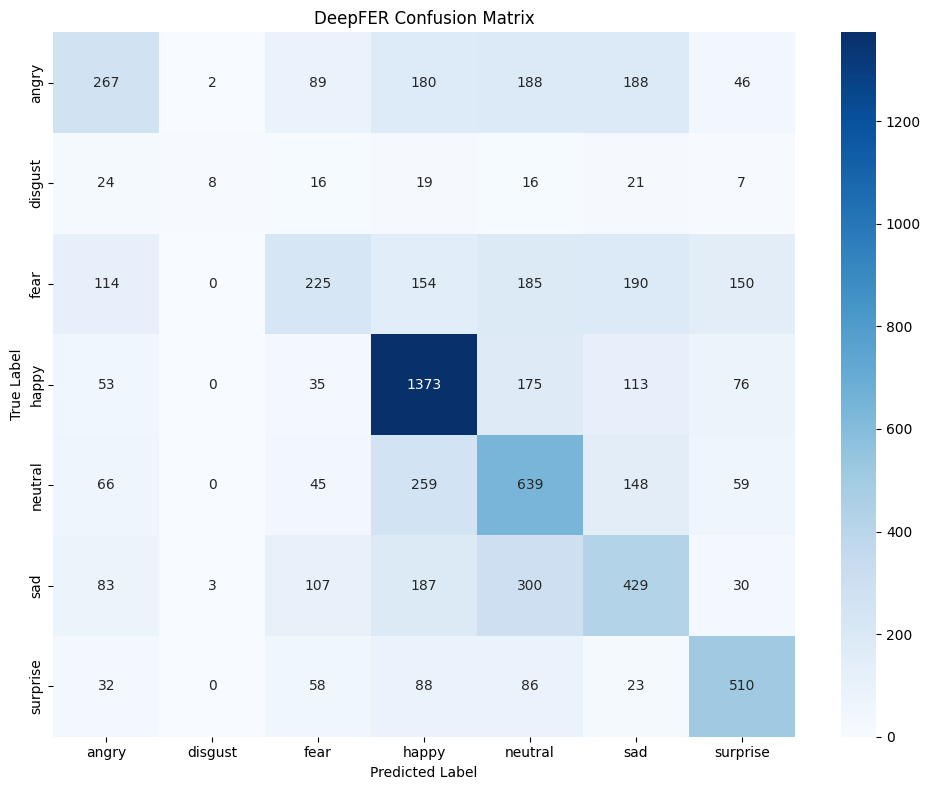

In [14]:
# ==========================================
# 7. EVALUATION & METRICS (15% Rubric)
# ==========================================


# Reset the validation generator back to the beginning.
#
# This is important because the generator may have already
# been used during model training.
#
# Resetting ensures that predictions start from the first
# validation image.
val_generator.reset()


# Use the trained model to make predictions on every
# image in the validation dataset.
#
# The result contains probabilities for each of the
# 7 emotion classes for every validation image.
predictions = model.predict(val_generator)


# Convert the probability predictions into class numbers.
#
# np.argmax() finds the position/index of the highest
# probability for each image.
#
# Example:
#
# Model output:
# [0.02, 0.01, 0.05, 0.85, 0.03, 0.02, 0.02]
#
# Highest probability = 0.85
# Its index = 3
#
# Therefore, the predicted class = 3.
y_pred = np.argmax(predictions, axis=1)


# Get the actual class labels of the validation images.
#
# val_generator.classes contains the true numeric class
# assigned to each validation image.
y_true = val_generator.classes


# Get the emotion class names from the directory structure.
#
# For example, this could produce:
#
# ['angry', 'disgust', 'fear', 'happy',
#  'neutral', 'sad', 'surprise']
#
# The exact order depends on class_indices.
class_labels = list(val_generator.class_indices.keys())


# ==========================================
# CLASSIFICATION REPORT
# ==========================================

print("\n--- CLASSIFICATION REPORT ---")


# Generate and display the classification report.
#
# The report provides:
# - Precision
# - Recall
# - F1-score
# - Support
#
# for each emotion class.
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_labels
    )
)


# ==========================================
# CONFUSION MATRIX
# ==========================================

# Compare the actual labels with the predicted labels
# and create a confusion matrix.
cm = confusion_matrix(y_true, y_pred)


# Create a figure with a size of 10 × 8 inches.
plt.figure(figsize=(10, 8))


# Display the confusion matrix as a heatmap.
#
# annot=True:
#     Display the actual numbers inside the cells.
#
# fmt='d':
#     Display values as integers.
#
# cmap='Blues':
#     Use a blue color scale.
#
# xticklabels:
#     Show emotion names along the predicted-label axis.
#
# yticklabels:
#     Show emotion names along the true-label axis.
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_labels,
    yticklabels=class_labels
)


# Add a title to the confusion matrix.
plt.title("DeepFER Confusion Matrix")


# X-axis represents the model's predicted emotion.
plt.xlabel("Predicted Label")


# Y-axis represents the actual emotion.
plt.ylabel("True Label")


# Automatically adjust spacing so labels fit properly.
plt.tight_layout()


# Save the confusion matrix as an image file.
#
# This creates:
# confusion_matrix.png
#
# You can use this image in your project report or presentation.
plt.savefig("confusion_matrix.png")


# Display the confusion matrix in the Colab notebook.
plt.show()

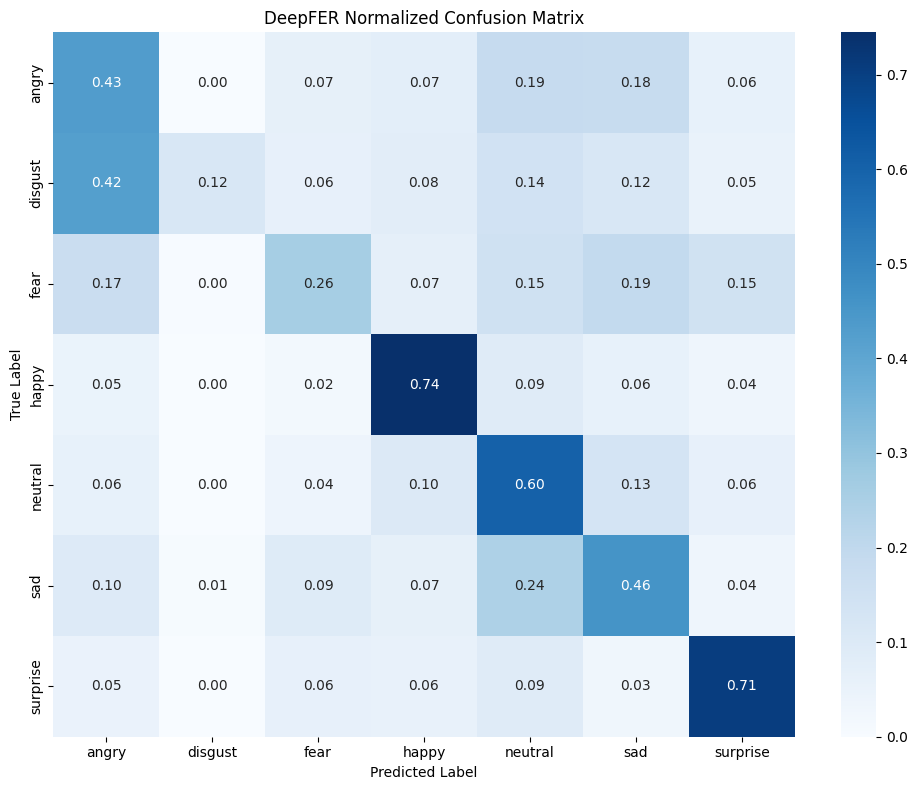

In [37]:
# ==========================================
# NORMALIZED CONFUSION MATRIX
# ==========================================

cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm_normalized,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.title("DeepFER Normalized Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()

plt.savefig("normalized_confusion_matrix.png")

plt.show()

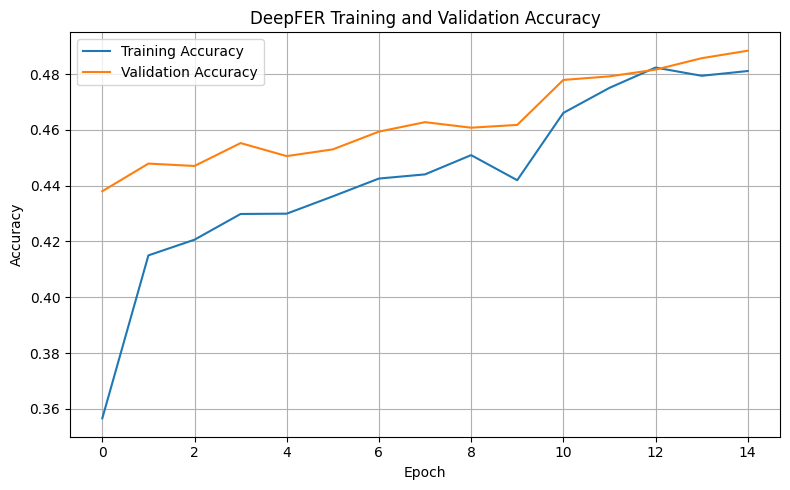

In [16]:
# ==========================================
# 8. TRAINING GRAPHS 📈
# ==========================================


import matplotlib.pyplot as plt

# ------------------------------------------
# TRAINING VS VALIDATION ACCURACY
# ------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title('DeepFER Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()

# Save graph for your project report
plt.savefig('accuracy_graph.png')

plt.show()


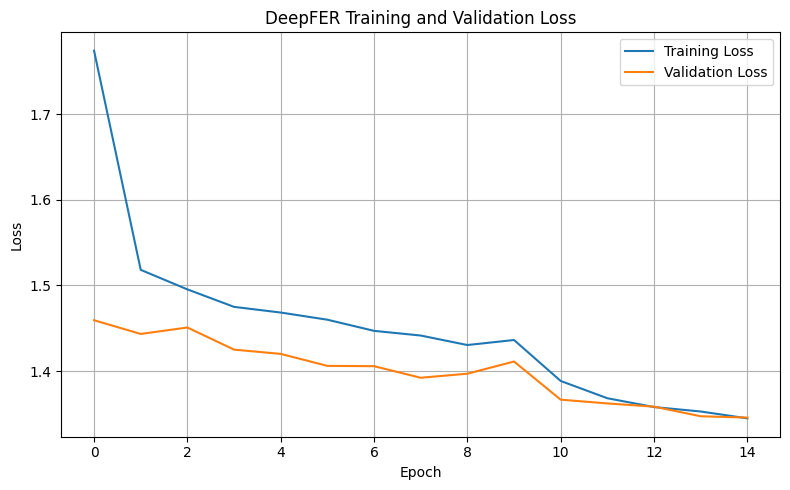

In [17]:
# ------------------------------------------
# TRAINING VS VALIDATION LOSS
# ------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title('DeepFER Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()

# Save graph for your project report
plt.savefig('loss_graph.png')

plt.show()


In [18]:
# ==========================================
# 9. FINAL PREDICTION ON AN IMAGE 🧑
# ==========================================

# SINGLE IMAGE EMOTION PREDICTION


from google.colab import files

uploaded = files.upload()


Saving Neha_linkdin.png to Neha_linkdin.png


1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step


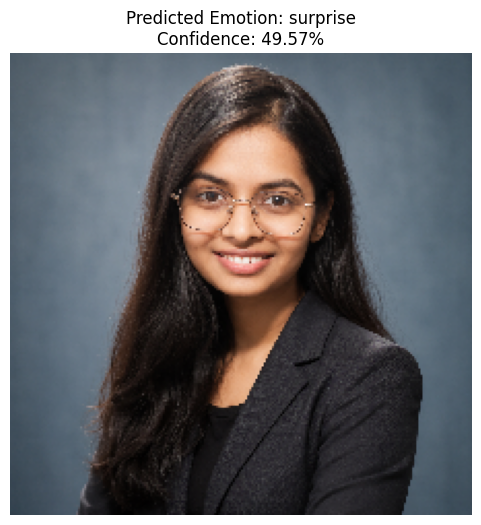

Predicted Emotion: surprise
Confidence: 49.57%


In [19]:
# ==========================================
# PREDICT EMOTION FROM UPLOADED IMAGE
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.utils import load_img, img_to_array


# Get the uploaded filename
image_path = list(uploaded.keys())[0]

# Load image and resize it to the same size
# used during model training.
img = load_img(
    image_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH)
)

# Convert image into a NumPy array
img_array = img_to_array(img)

# Add batch dimension.
#
# Before:
# (224, 224, 3)
#
# After:
# (1, 224, 224, 3)
img_array = np.expand_dims(img_array, axis=0)

# Apply the same normalization used during training.
img_array = img_array / 255.0


# Make prediction
prediction = model.predict(img_array)


# Find the class with the highest probability
predicted_index = np.argmax(prediction[0])


# Get predicted emotion name
predicted_emotion = class_labels[predicted_index]


# Get confidence percentage
confidence = prediction[0][predicted_index] * 100


# Display image
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis('off')

plt.title(
    f"Predicted Emotion: {predicted_emotion}\n"
    f"Confidence: {confidence:.2f}%"
)

plt.show()


print("Predicted Emotion:", predicted_emotion)
print(f"Confidence: {confidence:.2f}%")


In [22]:
# ==========================================
# 10. FINE-TUNING - LOAD BEST MODEL
# ==========================================

from tensorflow.keras.models import load_model

# Load the best model saved during initial training.
# compile=False avoids restoring the old optimizer/metric state
# because we will compile the model again for fine-tuning.
model = load_model(
    'deepfer_model.h5',
    compile=False
)

print("Best DeepFER model loaded successfully.")

Best DeepFER model loaded successfully.


In [23]:
# ==========================================
# 11. ENABLE FINE-TUNING
# ==========================================

# The first layer is the MobileNetV2 base model.
base_model = model.layers[0]

# First freeze the entire MobileNetV2 model.
base_model.trainable = False

# Unfreeze the last 20 layers so they can learn
# features specific to facial expressions.
for layer in base_model.layers[-20:]:
    layer.trainable = True

    # Keep Batch Normalization layers frozen.
    # This helps maintain stable feature statistics during
    # fine-tuning, especially when the dataset is not huge.
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

print("MobileNetV2 fine-tuning enabled.")

trainable_count = sum(
    layer.trainable for layer in base_model.layers
)

print("Trainable MobileNetV2 layers:", trainable_count)


MobileNetV2 fine-tuning enabled.
Trainable MobileNetV2 layers: 14


In [24]:
# ==========================================
# 12. RECOMPILE MODEL FOR FINE-TUNING
# ==========================================

from tensorflow.keras import optimizers

model.compile(
    optimizer=optimizers.Adam(
        learning_rate=1e-5
    ),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model recompiled successfully for fine-tuning.")


Model recompiled successfully for fine-tuning.


In [25]:
# ==========================================
# 13. FINE-TUNING TRAINING
# ==========================================

fine_tune_checkpoint = callbacks.ModelCheckpoint(
    'deepfer_finetuned_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

fine_tune_history = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    callbacks=[
        early_stopping,
        reduce_lr,
        fine_tune_checkpoint
    ]
)


Epoch 1/10
901/901 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step - accuracy: 0.4950 - loss: 1.3284
Epoch 1: val_accuracy improved from None to 0.49646, saving model to deepfer_finetuned_model.h5



Epoch 1: finished saving model to deepfer_finetuned_model.h5
901/901 ━━━━━━━━━━━━━━━━━━━━ 414s 438ms/step - accuracy: 0.4946 - loss: 1.3235 - val_accuracy: 0.4965 - val_loss: 1.3407 - learning_rate: 1.0000e-05
Epoch 2/10
901/901 ━━━━━━━━━━━━━━━━━━━━ 0s 379ms/step - accuracy: 0.5015 - loss: 1.3018
Epoch 2: val_accuracy improved from 0.49646 to 0.50693, saving model to deepfer_finetuned_model.h5



Epoch 2: finished saving model to deepfer_finetuned_model.h5
901/901 ━━━━━━━━━━━━━━━━━━━━ 350s 388ms/step - accuracy: 0.5032 - loss: 1.3010 - val_accuracy: 0.5069 - val_loss: 1.3057 - learning_rate: 1.0000e-05
Epoch 3/10
901/901 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step - accuracy: 0.5095 - loss: 1.2785
Epoch 3: val_accuracy improved from 0.50693 to 0.51613, saving model to deepfer_finetuned_model.h5



Epoch 3: finished saving model to deepfer_finetuned_model.h5
901/901 ━━━━━━━━━━━━━━━━━━━━ 362s 402ms/step - accuracy: 0.5109 - loss: 1.2761 - val_accuracy: 0.5161 - val_loss: 1.2886 - learning_rate: 1.0000e-05
Epoch 4/10
901/901 ━━━━━━━━━━━━━━━━━━━━ 0s 393ms/step - accuracy: 0.5166 - loss: 1.2696
Epoch 4: val_accuracy improved from 0.51613 to 0.52137, saving model to deepfer_finetuned_model.h5



Epoch 4: finished saving model to deepfer_finetuned_model.h5
901/901 ━━━━━━━━━━━━━━━━━━━━ 362s 402ms/step - accuracy: 0.5202 - loss: 1.2618 - val_accuracy: 0.5214 - val_loss: 1.2724 - learning_rate: 1.0000e-05
Epoch 5/10
901/901 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step - accuracy: 0.5245 - loss: 1.2478
Epoch 5: val_accuracy did not improve from 0.52137
901/901 ━━━━━━━━━━━━━━━━━━━━ 353s 391ms/step - accuracy: 0.5240 - loss: 1.2482 - val_accuracy: 0.4895 - val_loss: 1.3963 - learning_rate: 1.0000e-05
Epoch 6/10
901/901 ━━━━━━━━━━━━━━━━━━━━ 0s 381ms/step - accuracy: 0.5319 - loss: 1.2364
Epoch 6: val_accuracy improved from 0.52137 to 0.53312, saving model to deepfer_finetuned_model.h5



Epoch 6: finished saving model to deepfer_finetuned_model.h5
901/901 ━━━━━━━━━━━━━━━━━━━━ 351s 390ms/step - accuracy: 0.5309 - loss: 1.2379 - val_accuracy: 0.5331 - val_loss: 1.2497 - learning_rate: 1.0000e-05
Epoch 7/10
901/901 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step - accuracy: 0.5348 - loss: 1.2302
Epoch 7: val_accuracy did not improve from 0.53312
901/901 ━━━━━━━━━━━━━━━━━━━━ 353s 392ms/step - accuracy: 0.5353 - loss: 1.2254 - val_accuracy: 0.5260 - val_loss: 1.2742 - learning_rate: 1.0000e-05
Epoch 8/10
901/901 ━━━━━━━━━━━━━━━━━━━━ 0s 379ms/step - accuracy: 0.5299 - loss: 1.2256
Epoch 8: val_accuracy improved from 0.53312 to 0.54387, saving model to deepfer_finetuned_model.h5



Epoch 8: finished saving model to deepfer_finetuned_model.h5
901/901 ━━━━━━━━━━━━━━━━━━━━ 349s 388ms/step - accuracy: 0.5350 - loss: 1.2197 - val_accuracy: 0.5439 - val_loss: 1.2354 - learning_rate: 1.0000e-05
Epoch 9/10
901/901 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step - accuracy: 0.5437 - loss: 1.2065
Epoch 9: val_accuracy improved from 0.54387 to 0.54783, saving model to deepfer_finetuned_model.h5



Epoch 9: finished saving model to deepfer_finetuned_model.h5
901/901 ━━━━━━━━━━━━━━━━━━━━ 352s 391ms/step - accuracy: 0.5429 - loss: 1.2062 - val_accuracy: 0.5478 - val_loss: 1.2311 - learning_rate: 1.0000e-05
Epoch 10/10
901/901 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step - accuracy: 0.5495 - loss: 1.1907
Epoch 10: val_accuracy did not improve from 0.54783
901/901 ━━━━━━━━━━━━━━━━━━━━ 350s 388ms/step - accuracy: 0.5470 - loss: 1.1914 - val_accuracy: 0.5460 - val_loss: 1.2536 - learning_rate: 1.0000e-05
Restoring model weights from the end of the best epoch: 9.


In [26]:
# ==========================================
# 14. EVALUATE FINE-TUNED MODEL
# ==========================================

val_generator.reset()

predictions = model.predict(val_generator)

y_pred = np.argmax(predictions, axis=1)
y_true = val_generator.classes

class_labels = list(
    val_generator.class_indices.keys()
)

print("\n--- FINE-TUNED CLASSIFICATION REPORT ---")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_labels
    )
)


221/221 ━━━━━━━━━━━━━━━━━━━━ 17s 55ms/step

--- FINE-TUNED CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

       angry       0.44      0.43      0.43       960
     disgust       0.50      0.12      0.19       111
        fear       0.46      0.26      0.33      1018
       happy       0.78      0.74      0.76      1825
     neutral       0.46      0.60      0.52      1216
         sad       0.43      0.46      0.45      1139
    surprise       0.58      0.71      0.64       797

    accuracy                           0.55      7066
   macro avg       0.52      0.47      0.47      7066
weighted avg       0.55      0.55      0.54      7066



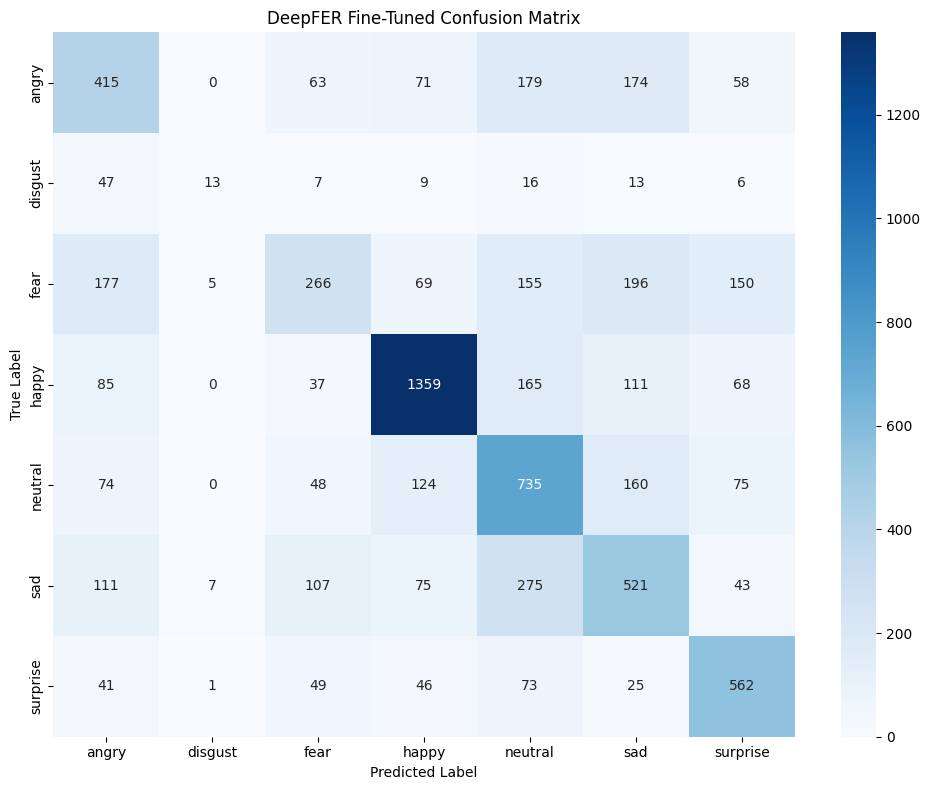

In [27]:
# ==========================================
# 15. FINE-TUNED CONFUSION MATRIX
# ==========================================

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.title("DeepFER Fine-Tuned Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()

plt.savefig("fine_tuned_confusion_matrix.png")

plt.show()


In [28]:
!pip install -q gradio


📷 Starting your MacBook camera...
Allow camera access if Chrome asks for permission.


<IPython.core.display.Javascript object>

✅ Photo captured successfully!


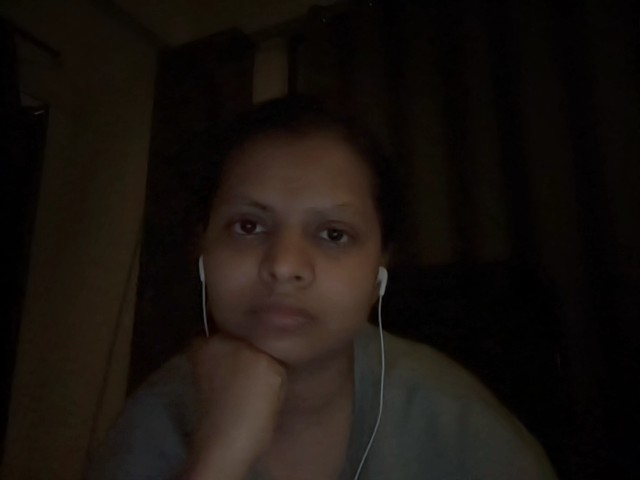

In [40]:
# ==========================================
# 16. REAL-TIME / WEBCAM DEMO
# ==========================================
# ==========================================
# FINAL DEEPFER LAPTOP CAMERA DEMO
# ==========================================

import base64
import io
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from IPython.display import display, Javascript
from google.colab.output import eval_js
from tensorflow.keras.preprocessing.image import img_to_array


# ------------------------------------------------
# Emotion classes
# ------------------------------------------------

class_labels = [
    "angry",
    "disgust",
    "fear",
    "happy",
    "neutral",
    "sad",
    "surprise"
]


# ------------------------------------------------
# JavaScript camera function
# This accesses your MacBook's built-in camera
# through Chrome.
# ------------------------------------------------

def take_photo():

    js = Javascript('''
    async function takePhoto() {

        const div = document.createElement('div');

        const video = document.createElement('video');

        const button = document.createElement('button');
        button.textContent = 'CAPTURE PHOTO';

        const stopButton = document.createElement('button');
        stopButton.textContent = 'STOP CAMERA';

        div.appendChild(video);
        div.appendChild(document.createElement('br'));
        div.appendChild(button);
        div.appendChild(stopButton);

        document.body.appendChild(div);

        const stream = await navigator.mediaDevices.getUserMedia({
            video: true
        });

        video.srcObject = stream;

        await video.play();

        // Wait until user presses Capture Photo
        await new Promise((resolve) => {
            button.onclick = resolve;
        });

        const canvas = document.createElement('canvas');

        canvas.width = video.videoWidth;
        canvas.height = video.videoHeight;

        canvas.getContext('2d').drawImage(
            video,
            0,
            0,
            canvas.width,
            canvas.height
        );

        // Stop camera
        stream.getTracks().forEach(track => track.stop());

        div.remove();

        return canvas.toDataURL('image/jpeg', 0.9);
    }

    takePhoto();
    ''')

    display(js)

    data = eval_js('takePhoto()')

    binary = base64.b64decode(
        data.split(',')[1]
    )

    return binary


# ------------------------------------------------
# Capture image
# ------------------------------------------------

print("📷 Starting your MacBook camera...")
print("Allow camera access if Chrome asks for permission.")

image_bytes = take_photo()

image = Image.open(
    io.BytesIO(image_bytes)
)

print("✅ Photo captured successfully!")

display(image)

        DeepFER EMOTION PREDICTION
Predicted Emotion : SAD
Confidence        : 60.91%


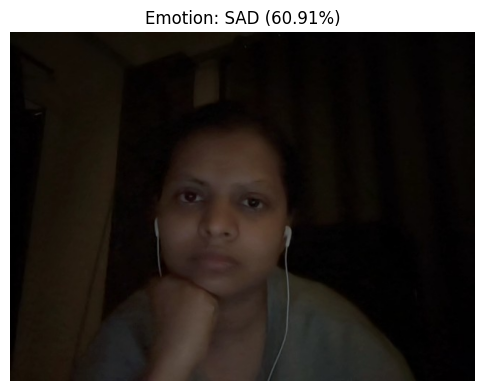

In [41]:
# ==========================================
# DEEPFER EMOTION PREDICTION
# ==========================================

# Resize image to MobileNetV2 input size
img = image.resize((IMG_WIDTH, IMG_HEIGHT))

# Convert image to NumPy array
img_array = np.array(img)

# Make sure image has 3 RGB channels
if img_array.shape[-1] == 4:
    img_array = img_array[:, :, :3]

# Normalize pixel values
img_array = img_array.astype("float32") / 255.0

# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)

# Predict emotion
predictions = model.predict(
    img_array,
    verbose=0
)

# Get predicted class
predicted_index = np.argmax(predictions[0])

predicted_emotion = class_labels[predicted_index]

# Get confidence
confidence = predictions[0][predicted_index] * 100


# ------------------------------------------------
# Display result
# ------------------------------------------------

print("=" * 50)
print("        DeepFER EMOTION PREDICTION")
print("=" * 50)

print(f"Predicted Emotion : {predicted_emotion.upper()}")
print(f"Confidence        : {confidence:.2f}%")

print("=" * 50)


# Display image with prediction
plt.figure(figsize=(6, 6))

plt.imshow(image)
plt.axis("off")

plt.title(
    f"Emotion: {predicted_emotion.upper()} "
    f"({confidence:.2f}%)"
)

plt.show()

Final Conclusion

Conclusion

The DeepFER (Facial Emotion Recognition Using Deep Learning) project was successfully developed to recognize human facial emotions using deep learning and transfer learning techniques. The system uses MobileNetV2, a pre-trained convolutional neural network, as the feature extraction backbone and a custom classification layer to classify facial expressions into seven emotion categories: angry, disgust, fear, happy, neutral, sad, and surprise.

The project included important data preparation and machine learning steps such as dataset validation and cleaning, image resizing, normalization, data augmentation, transfer learning, model training, optimization, and evaluation. Data augmentation was used to introduce variations in the training images and improve the model's ability to generalize to different facial expressions and image conditions.

The trained model was evaluated using a classification report and confusion matrix, which provided class-wise precision, recall, F1-score, and overall performance. The confusion matrix also helped identify which emotions were easier or more difficult for the model to distinguish.

Furthermore, fine-tuning of the MobileNetV2 model was incorporated by making the later layers trainable while keeping most of the pre-trained layers frozen. This allows the model to adapt its learned visual features to the facial-expression recognition task while reducing the risk of overfitting.

Finally, a camera-based prediction demonstration was implemented using the laptop's built-in camera. The system successfully captured a facial image and generated an emotion prediction with a confidence score, demonstrating the complete pipeline from image acquisition to emotion classification.

Overall, DeepFER demonstrates how CNN-based transfer learning can be applied to facial emotion recognition and provides a foundation for real-world applications such as human-computer interaction, customer-service systems, and interactive AI applications. The system can be further improved through larger and more diverse datasets, stronger face detection, additional fine-tuning, independent testing, and deployment as a standalone application.